# TM-015: Class-Imbalance Experiments

**Financial Tweet Sentiment Classification / Nova IMS Text Mining 2025-2026**

The EDA showed roughly 65% of the training set is Neutral and only 15% is Bearish. Some models in `Model.ipynb` already used `class_weight='balanced'`, but we never compared that against resampling or against doing nothing at all. This notebook runs the same model families under four conditions and compares F1 macro and per-class F1 to pick the best approach for the rest of the project.

In [8]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\pedro\Documentos\NOVA IMS\2º semestre- eu\Text mining\TextMining-Corpora


In [9]:
!pip install xgboost
!pip install imblearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from src.config import TRAIN_CSV_PATH, SEED, LABEL_NAMES
from src.preprocessing import preprocess_tweet, stratified_split
from src.evaluate import evaluate_and_log

sns.set_theme(style="whitegrid")

## 1. Load, preprocess, vectorize

Same split and TF-IDF config as `Model.ipynb` Section 6 so results are directly comparable.

In [10]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
X_train_raw, X_val_raw, y_train, y_val = stratified_split(train_df)

X_train_pre = X_train_raw.apply(lambda t: preprocess_tweet(t, return_str=True))
X_val_pre = X_val_raw.apply(lambda t: preprocess_tweet(t, return_str=True))

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000)
X_train_tfidf = vec.fit_transform(X_train_pre)
X_val_tfidf = vec.transform(X_val_pre)

print(f"Train: {X_train_tfidf.shape}, Val: {X_val_tfidf.shape}")
print(f"Class distribution: {pd.Series(y_train).value_counts().sort_index().rename(LABEL_NAMES).to_dict()}")

Train: (7634, 11028), Val: (1909, 11028)
Class distribution: {'Bearish': 1154, 'Bullish': 1538, 'Neutral': 4942}


## 2. Build resampled training sets

In [11]:
ros = RandomOverSampler(random_state=SEED)
X_over, y_over = ros.fit_resample(X_train_tfidf, y_train)

rus = RandomUnderSampler(random_state=SEED)
X_under, y_under = rus.fit_resample(X_train_tfidf, y_train)

print("Original:    ", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Oversampled: ", pd.Series(y_over).value_counts().sort_index().to_dict())
print("Undersampled:", pd.Series(y_under).value_counts().sort_index().to_dict())

Original:     {0: 1154, 1: 1538, 2: 4942}
Oversampled:  {0: 4942, 1: 4942, 2: 4942}
Undersampled: {0: 1154, 1: 1154, 2: 1154}


## 3. Run the experiment grid

Four strategies, five model families (best config from each). `class_weight` only goes to LR and RF since the others do not support it natively.

In [12]:
strategies = {
    "none":         (X_train_tfidf, y_train, None),
    "class_weight": (X_train_tfidf, y_train, "balanced"),
    "oversample":   (X_over,        y_over,  None),
    "undersample":  (X_under,       y_under, None),
}


def make_models(cw=None):
    return {
        "LR":  LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000,
                                  class_weight=cw, random_state=SEED),
        "MNB": MultinomialNB(alpha=0.1),
        "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), learning_rate_init=0.001,
                             early_stopping=True, random_state=SEED, max_iter=500),
        "RF":  RandomForestClassifier(n_estimators=200, max_depth=20,
                                      class_weight=cw, random_state=SEED, n_jobs=-1),
        "XGB": XGBClassifier(max_depth=6, learning_rate=0.05, n_estimators=200,
                             random_state=SEED, n_jobs=-1),
    }


rows = []
best_f1, best_pred, best_tag = 0, None, ""

for strat, (X_tr, y_tr, cw) in strategies.items():
    clfs = make_models(cw)
    for name, clf in clfs.items():
        # class_weight only applies to LR and RF
        if strat == "class_weight" and name not in ("LR", "RF"):
            continue

        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val_tfidf)
        f1m = f1_score(y_val, y_pred, average="macro")
        f1_cls = f1_score(y_val, y_pred, average=None)

        rows.append({
            "strategy": strat, "model": name,
            "f1_macro": round(f1m, 4),
            "f1_bearish": round(f1_cls[0], 4),
            "f1_bullish": round(f1_cls[1], 4),
            "f1_neutral": round(f1_cls[2], 4),
        })

        if f1m > best_f1:
            best_f1 = f1m
            best_pred = y_pred.copy()
            best_tag = f"{name} + {strat}"

imb_df = pd.DataFrame(rows)
print(f"Ran {len(rows)} experiments. Best so far: {best_tag} (F1 = {best_f1:.4f})")

Ran 17 experiments. Best so far: LR + class_weight (F1 = 0.7113)


## 4. Comparison tables

In [13]:
print("=== F1 Macro ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_macro").round(4).to_string())

print()
print("=== F1 Bearish (minority class) ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_bearish").round(4).to_string())

print()
print("=== F1 Bullish ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_bullish").round(4).to_string())

print()
print("=== F1 Neutral ===")
print()
print(imb_df.pivot(index="model", columns="strategy", values="f1_neutral").round(4).to_string())

=== F1 Macro ===

strategy  class_weight    none  oversample  undersample
model                                                  
LR              0.7113  0.6417      0.7085       0.6652
MLP                NaN  0.6830      0.6884       0.6384
MNB                NaN  0.6793      0.6754       0.6356
RF              0.6589  0.3313      0.6326       0.6311
XGB                NaN  0.5659      0.6377       0.6193

=== F1 Bearish (minority class) ===

strategy  class_weight    none  oversample  undersample
model                                                  
LR              0.5971  0.4581      0.5878       0.5242
MLP                NaN  0.5386      0.5364       0.5207
MNB                NaN  0.5411      0.5396       0.5194
RF              0.5429  0.0274      0.5051       0.5038
XGB                NaN  0.3743      0.5017       0.4780

=== F1 Bullish ===

strategy  class_weight    none  oversample  undersample
model                                                  
LR              0.6762  0.6

## 5. Best strategy per model

In [14]:
best_per = imb_df.loc[imb_df.groupby("model")["f1_macro"].idxmax()]
print("Best strategy for each model:")
print()
print(best_per[["model", "strategy", "f1_macro", "f1_bearish", "f1_bullish", "f1_neutral"]].to_string(index=False))

winner = imb_df.loc[imb_df["f1_macro"].idxmax()]
print(f"\nWinner: {winner['model']} + {winner['strategy']} (F1 macro = {winner['f1_macro']:.4f})")

Best strategy for each model:

model     strategy  f1_macro  f1_bearish  f1_bullish  f1_neutral
   LR class_weight    0.7113      0.5971      0.6762      0.8607
  MLP   oversample    0.6884      0.5364      0.6667      0.8621
  MNB         none    0.6793      0.5411      0.6289      0.8678
   RF class_weight    0.6589      0.5429      0.5916      0.8421
  XGB   oversample    0.6377      0.5017      0.5806      0.8308

Winner: LR + class_weight (F1 macro = 0.7113)


## 6. Per-class F1 chart

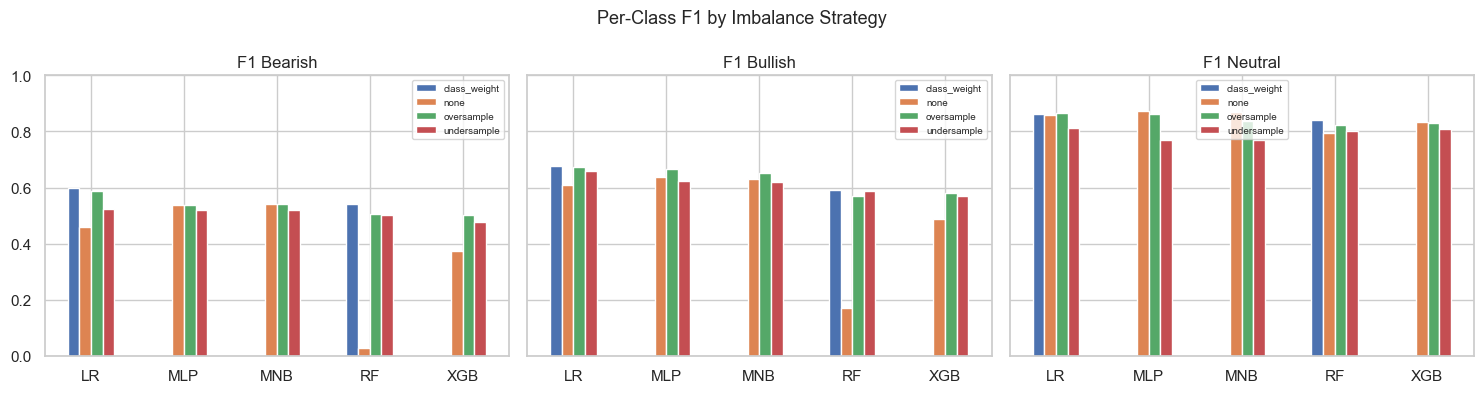

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col, title in zip(axes,
    ["f1_bearish", "f1_bullish", "f1_neutral"],
    ["Bearish", "Bullish", "Neutral"]):
    piv = imb_df.pivot(index="model", columns="strategy", values=col)
    piv.plot.bar(ax=ax, rot=0)
    ax.set_title(f"F1 {title}")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)

fig.suptitle("Per-Class F1 by Imbalance Strategy", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/imbalance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Log the winner to the leaderboard

In [20]:
full_names = {
    "LR": "Logistic Regression", "MNB": "Multinomial NB",
    "MLP": "MLP Classifier", "RF": "Random Forest", "XGB": "XGBoost",
}

evaluate_and_log(
    y_val, best_pred,
    model_name=full_names[winner["model"]],
    feature_desc="TF-IDF (1,2) Optimized",
    params=f"best_imbalance_strategy={winner['strategy']} (TM-015 winner)",
    owner="Pedro",
)


MODEL EVALUATION: Logistic Regression (TF-IDF (1,2) Optimized)
[INFO] Accuracy          : 0.7810
[INFO] Precision (Macro) : 0.7041
[INFO] Recall (Macro)    : 0.7201
[INFO] F1 (Macro)        : 0.7113
------------------------------------------------------------
              precision    recall  f1-score   support

     Bearish       0.56      0.64      0.60       288
     Bullish       0.67      0.68      0.68       385
     Neutral       0.87      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.72      0.71      1909
weighted avg       0.79      0.78      0.78      1909

------------------------------------------------------------
[[ 183   44   61]
 [  35  261   89]
 [ 107   82 1047]]
[INFO] Added run in outputs/results.csv


{'accuracy': 0.7810371922472499,
 'precision_macro': 0.7040607481733553,
 'recall_macro': 0.720142041076507,
 'f1_macro': 0.711298423092834,
 'f1_per_class': {'Bearish': 0.5970636215334421,
  'Bullish': 0.6761658031088082,
  'Neutral': 0.8606658446362515}}